# Olist Cohort EDA

Global late-rate averages hide the segments where the problem lives. This notebook cuts the delivered-only dataset into cohorts and asks where late risk concentrates:

1. **Seller volume** - are low-volume sellers more failure-prone than high-volume ones, or the opposite?
2. **Item count** - do larger baskets, which are harder to pack and dispatch, arrive late more often?
3. **Product weight** - do heavier orders (likely shipped by different carrier lanes) behave differently?
4. **Product category** - which categories carry the most delay risk, and which are safest?
5. **Missing product metadata as signal** - the feature set already exposes `missing_product_metadata_share`; this section checks whether missing metadata is associated with higher delay risk so we can treat missingness as real signal rather than noise.

All groupings apply a minimum volume threshold so the rankings are not dominated by a handful of orders.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.io import load_olist_tables
from src.data.prepare import build_modeling_frame
from src.features.engineering import build_model_dataset

sns.set_theme(style='whitegrid')

tables = load_olist_tables(ROOT / 'data' / 'raw')
modeling_frame = build_modeling_frame(tables)
dataset = build_model_dataset(modeling_frame)
BASE_RATE = dataset['is_late'].mean()
MIN_COHORT_ORDERS = 200
print(f'Rows: {len(dataset):,}')
print(f'Base late rate: {BASE_RATE:.2%}')
print(f'Min cohort size for rankings: {MIN_COHORT_ORDERS} orders')

Rows: 96,470
Base late rate: 8.11%
Min cohort size for rankings: 200 orders


## 1. Seller volume cohorts

Each order's **primary seller** is the mode seller across its items. Seller volume is the total distinct orders that seller appears in across the dataset. The hypothesis is asymmetric: high-volume sellers have either industrialized their fulfillment (lower late rate) or are so stretched that they fail at scale (higher late rate). Both are plausible; the data decides.

In [2]:
order_items = tables['order_items']

def _mode_or_none(series):
    mode = series.mode()
    return mode.iloc[0] if not mode.empty else None

primary_seller = (
    order_items.groupby('order_id')['seller_id']
    .agg(_mode_or_none)
    .rename('primary_seller_id')
    .reset_index()
)
seller_volumes = (
    order_items.groupby('seller_id')['order_id'].nunique().rename('seller_orders')
)
primary_seller = primary_seller.merge(
    seller_volumes, left_on='primary_seller_id', right_index=True, how='left'
)

cohort = dataset.merge(primary_seller, on='order_id', how='left')
print(f'Orders with a primary seller matched: {cohort["primary_seller_id"].notna().sum():,}')

Orders with a primary seller matched: 96,470


In [3]:
bins = [0, 10, 50, 200, 1000, max(1001, int(cohort['seller_orders'].max()) + 1)]
labels = ['1-10', '11-50', '51-200', '201-1000', '1000+']
cohort['seller_volume_bucket'] = pd.cut(
    cohort['seller_orders'], bins=bins, labels=labels, include_lowest=True
)

seller_bucket_stats = (
    cohort.groupby('seller_volume_bucket', observed=True)
    .agg(orders=('is_late', 'size'), late_rate=('is_late', 'mean'))
    .reset_index()
)
seller_bucket_stats['lift_vs_base'] = (seller_bucket_stats['late_rate'] / BASE_RATE).round(2)
seller_bucket_stats

,seller_volume_bucket,orders,late_rate,lift_vs_base
0,1-10,6239,0.082866,1.02
1,11-50,17410,0.080930,1.00
2,51-200,30930,0.076528,0.94
3,201-1000,28330,0.084645,1.04
4,1000+,13561,0.083696,1.03


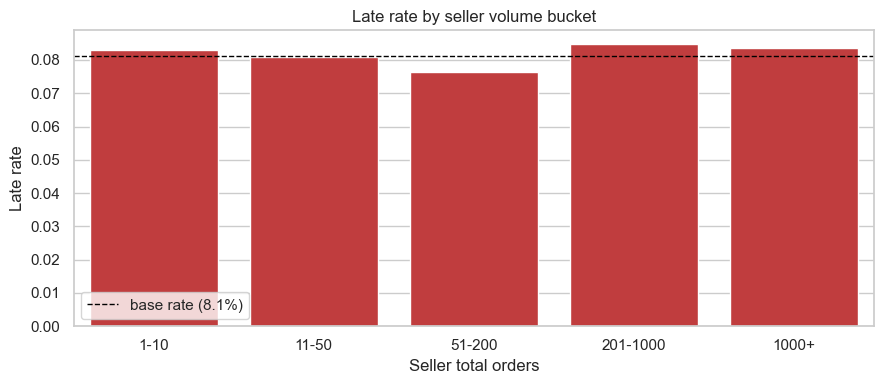

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    data=seller_bucket_stats, x='seller_volume_bucket', y='late_rate', color='tab:red', ax=ax
)
ax.axhline(BASE_RATE, linestyle='--', color='black', linewidth=1, label=f'base rate ({BASE_RATE:.1%})')
ax.set_title('Late rate by seller volume bucket')
ax.set_xlabel('Seller total orders')
ax.set_ylabel('Late rate')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Item count cohorts

Orders with more items are usually harder to pick, pack and hand off. If the signal is strong, a simple ordinal bucket is a cheap feature; if it is flat, then the dataset's multi-item orders are rare enough that basket size does not matter.

In [5]:
item_bins = [0, 1, 2, 4, 99]
item_labels = ['1', '2', '3-4', '5+']
cohort['item_count_bucket'] = pd.cut(
    cohort['item_count'], bins=item_bins, labels=item_labels, include_lowest=True
)

item_stats = (
    cohort.groupby('item_count_bucket', observed=True)
    .agg(orders=('is_late', 'size'), late_rate=('is_late', 'mean'))
    .reset_index()
)
item_stats['lift_vs_base'] = (item_stats['late_rate'] / BASE_RATE).round(2)
item_stats

,item_count_bucket,orders,late_rate,lift_vs_base
0,1,86835,0.082881,1.02
1,2,7392,0.066288,0.82
2,3-4,1801,0.060522,0.75
3,5+,442,0.067873,0.84


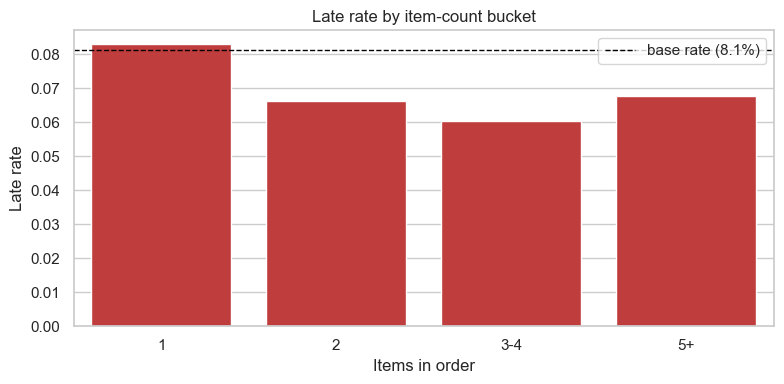

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=item_stats, x='item_count_bucket', y='late_rate', color='tab:red', ax=ax)
ax.axhline(BASE_RATE, linestyle='--', color='black', linewidth=1, label=f'base rate ({BASE_RATE:.1%})')
ax.set_title('Late rate by item-count bucket')
ax.set_xlabel('Items in order')
ax.set_ylabel('Late rate')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Product weight cohorts

`avg_product_weight_g` is the mean product weight across the order's items. Heavy orders typically route through different carrier lanes and can have different SLA profiles. The buckets are quantile-based so each bucket has a comparable order count.

In [7]:
weight = cohort.dropna(subset=['avg_product_weight_g']).copy()
weight['weight_bucket'] = pd.qcut(
    weight['avg_product_weight_g'],
    q=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['q1 (lightest)', 'q2', 'q3', 'q4', 'q5 (heaviest)'],
    duplicates='drop',
)

weight_stats = (
    weight.groupby('weight_bucket', observed=True)
    .agg(
        orders=('is_late', 'size'),
        late_rate=('is_late', 'mean'),
        median_weight_g=('avg_product_weight_g', 'median'),
    )
    .reset_index()
)
weight_stats['lift_vs_base'] = (weight_stats['late_rate'] / BASE_RATE).round(2)
weight_stats

,weight_bucket,orders,late_rate,median_weight_g,lift_vs_base
0,q1 (lightest),22323,0.073467,180.0,0.91
1,q2,18457,0.082462,373.0,1.02
2,q3,17193,0.077124,700.0,0.95
3,q4,19533,0.083551,1538.0,1.03
4,q5 (heaviest),18948,0.090036,6325.0,1.11


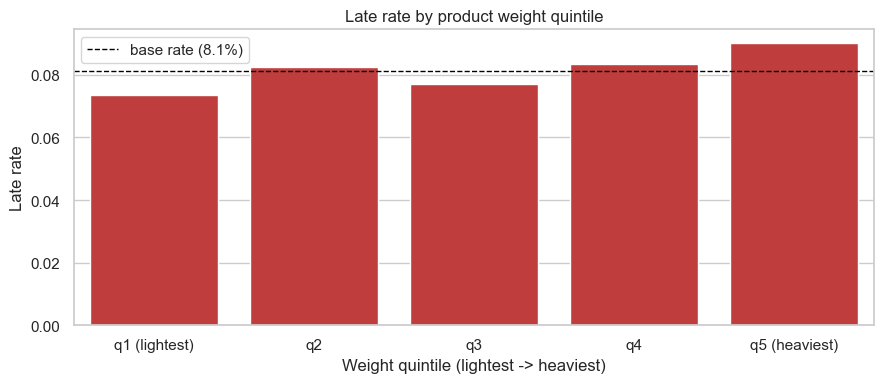

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=weight_stats, x='weight_bucket', y='late_rate', color='tab:red', ax=ax)
ax.axhline(BASE_RATE, linestyle='--', color='black', linewidth=1, label=f'base rate ({BASE_RATE:.1%})')
ax.set_title('Late rate by product weight quintile')
ax.set_xlabel('Weight quintile (lightest -> heaviest)')
ax.set_ylabel('Late rate')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Product category cohorts

Category is not part of the current feature set. This section joins it in from the raw `products` table so we can see whether some categories drive most of the delay risk. Each order gets its mode category (ties broken by first). Only categories with at least `MIN_COHORT_ORDERS` orders are ranked.

In [9]:
products = tables['products'][['product_id', 'product_category_name']]

item_categories = order_items[['order_id', 'product_id']].merge(
    products, on='product_id', how='left'
)
primary_category = (
    item_categories.groupby('order_id')['product_category_name']
    .agg(_mode_or_none)
    .rename('primary_category')
    .reset_index()
)
cohort = cohort.merge(primary_category, on='order_id', how='left')

category_stats = (
    cohort.dropna(subset=['primary_category'])
    .groupby('primary_category')
    .agg(orders=('is_late', 'size'), late_rate=('is_late', 'mean'))
    .reset_index()
)
category_stats['lift_vs_base'] = (category_stats['late_rate'] / BASE_RATE).round(2)
viable_categories = category_stats[category_stats['orders'] >= MIN_COHORT_ORDERS]
print(
    f'{len(viable_categories)} categories with >= {MIN_COHORT_ORDERS} orders '
    f'(out of {len(category_stats)} total)'
)

42 categories with >= 200 orders (out of 73 total)


In [10]:
riskiest_categories = viable_categories.sort_values('late_rate', ascending=False).head(12)
riskiest_categories

,primary_category,orders,late_rate,lift_vs_base
7,audio,348,0.129310,1.59
49,livros_tecnicos,254,0.110236,1.36
14,casa_conforto,349,0.108883,1.34
1,alimentos,439,0.100228,1.24
30,eletronicos,2509,0.098446,1.21
23,construcao_ferramentas_iluminacao,236,0.093220,1.15
55,moveis_escritorio,1244,0.092444,1.14
9,bebes,2794,0.092341,1.14
21,construcao_ferramentas_construcao,731,0.091655,1.13
11,beleza_saude,8636,0.089625,1.10


In [11]:
safest_categories = viable_categories.sort_values('late_rate').head(12)
safest_categories

,primary_category,orders,late_rate,lift_vs_base
19,climatizacao,246,0.040650,0.50
53,moveis_cozinha_area_de_servico_jantar_e_jardim,238,0.046218,0.57
51,market_place,267,0.048689,0.60
71,telefonia_fixa,210,0.052381,0.65
50,malas_acessorios,1010,0.054455,0.67
31,eletroportateis,604,0.062914,0.78
63,pet_shop,1679,0.063133,0.78
2,alimentos_bebidas,220,0.063636,0.78
34,fashion_calcados,233,0.064378,0.79
10,bebidas,285,0.066667,0.82


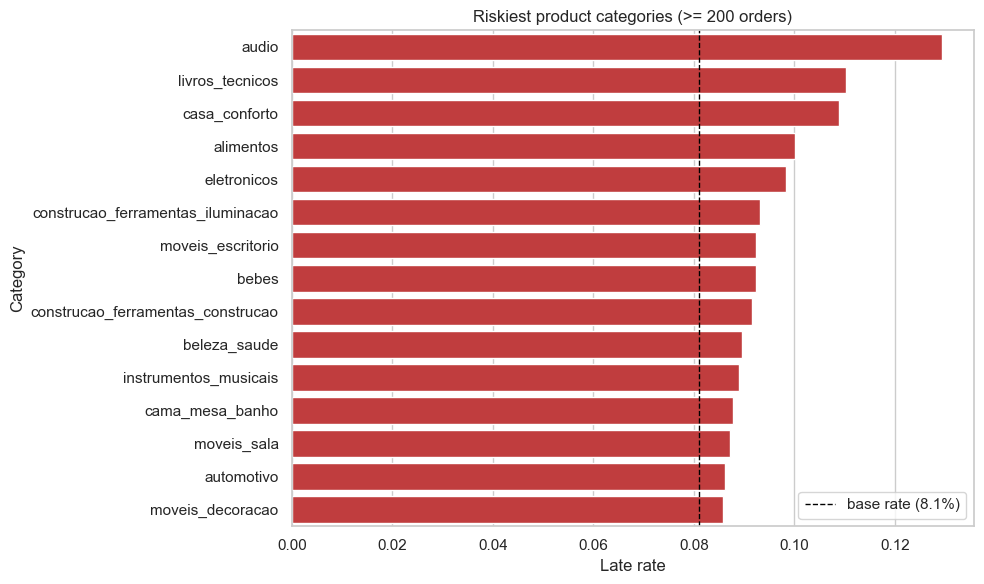

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
riskiest = viable_categories.sort_values('late_rate', ascending=False).head(15)
sns.barplot(data=riskiest, y='primary_category', x='late_rate', color='tab:red', ax=ax)
ax.axvline(BASE_RATE, linestyle='--', color='black', linewidth=1, label=f'base rate ({BASE_RATE:.1%})')
ax.set_title(f'Riskiest product categories (>= {MIN_COHORT_ORDERS} orders)')
ax.set_xlabel('Late rate')
ax.set_ylabel('Category')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Missing product metadata as signal

`missing_product_metadata_share` is already in the feature set. It measures the fraction of an order's items that have no product weight/dimensions/photos/text metadata at all. The question is whether that missingness is **signal** (missing metadata is associated with worse fulfillment) or **noise** (distributed independently of delay risk). If it is signal, the existing feature is doing useful work; if it is noise, the feature can eventually be dropped.

In [13]:
def _missing_bucket(share: float) -> str:
    if pd.isna(share):
        return 'no_items'
    if share == 0:
        return 'all_metadata_present'
    if share < 1:
        return 'partial'
    return 'all_metadata_missing'

cohort['metadata_bucket'] = cohort['missing_product_metadata_share'].apply(_missing_bucket)
metadata_stats = (
    cohort.groupby('metadata_bucket')
    .agg(orders=('is_late', 'size'), late_rate=('is_late', 'mean'))
    .reindex(['all_metadata_present', 'partial', 'all_metadata_missing', 'no_items'])
    .dropna()
    .reset_index()
)
metadata_stats['lift_vs_base'] = (metadata_stats['late_rate'] / BASE_RATE).round(2)
metadata_stats

,metadata_bucket,orders,late_rate,lift_vs_base
0,all_metadata_present,96455.0,0.081136,1.0
1,all_metadata_missing,15.0,0.000000,0.0


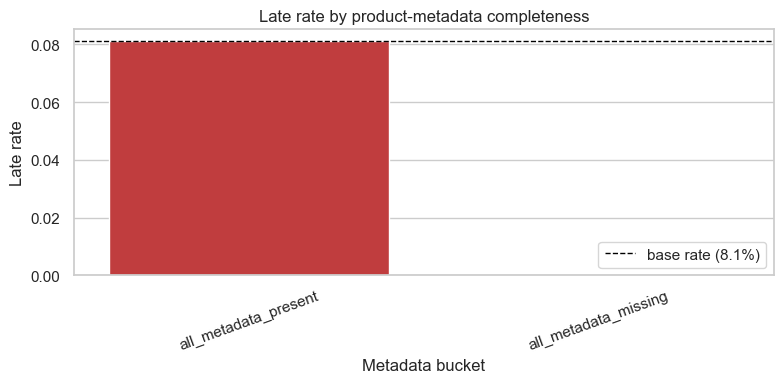

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=metadata_stats,
    x='metadata_bucket',
    y='late_rate',
    color='tab:red',
    ax=ax,
)
ax.axhline(BASE_RATE, linestyle='--', color='black', linewidth=1, label=f'base rate ({BASE_RATE:.1%})')
ax.set_title('Late rate by product-metadata completeness')
ax.set_xlabel('Metadata bucket')
ax.set_ylabel('Late rate')
ax.tick_params(axis='x', rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

## Takeaways

Use the tables above to fill in the specific numbers, but the structural reads are:

- **Seller volume.** If a clear monotonic trend exists, consider a log-seller-volume feature or a target-encoded seller id. If it is U-shaped, bucket the feature instead of using it linearly.
- **Item count / weight.** Both are already numeric features in the model. These plots justify whether they are carrying weight or are dead columns.
- **Category.** If a handful of categories contain most of the delay mass, a target-encoded category feature is probably worth adding to `src/features/engineering.py`. If the ranking is flat, leave it out and keep the feature set lean.
- **Missing metadata as signal.** If the `all_metadata_missing` bucket has meaningfully higher late rates than `all_metadata_present`, the current feature is doing real work and we should keep it; if the rates are indistinguishable, it is a candidate for removal during the next feature audit.

These cohort views are descriptive, not causal. A high-risk category might just be a proxy for heavy, bulky items routed through slower carrier lanes. Treat the findings as hypotheses for permutation-importance and error-analysis follow-ups in `02_eda.ipynb` and the model-training pipeline.